# Phishing Email Detection
### DMML Mini Project

This notebook builds a text classification model to detect phishing emails using NLP.

**Datasets used:**
- Ling-Spam Corpus (legitimate + phishing)
- Nazario Phishing Corpus (phishing)
- Nigerian Fraud emails (phishing)
- SpamAssasin (spam treated as phishing + legitimate)

**Label convention:** 0 = Legitimate, 1 = Phishing

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## 2. Load and Combine Datasets

In [3]:
ling     = pd.read_csv('Ling.csv')
nazario  = pd.read_csv('Nazario.csv')
nigerian = pd.read_csv('Nigerian_Fraud.csv')
spam     = pd.read_csv('SpamAssasin.csv')

def standardise(df):
    d = df.copy()
    d['text'] = d['subject'].fillna('') + ' ' + d['body'].fillna('')
    return d[['text', 'label']]
combined = pd.concat(
    [standardise(ling), standardise(nazario), standardise(nigerian), standardise(spam)],
    ignore_index=True
)
combined.dropna(subset=['text', 'label'], inplace=True)
combined['label'] = combined['label'].astype(int)
print('Total emails :', len(combined))
print('Legitimate   :', (combined.label == 0).sum())
print('Phishing     :', (combined.label == 1).sum())
combined.head()

Total emails : 13565
Legitimate   : 6492
Phishing     : 7073


,text,label
0,job posting - apple-iss research center conten...,0
1,"lang classification grimes , joseph e . and b...",0
2,query : letter frequencies for text identifica...,0
3,risk a colleague and i are researching the dif...,0
4,request book information earlier this morning ...,0


## 3. Pictorial Data Analysis

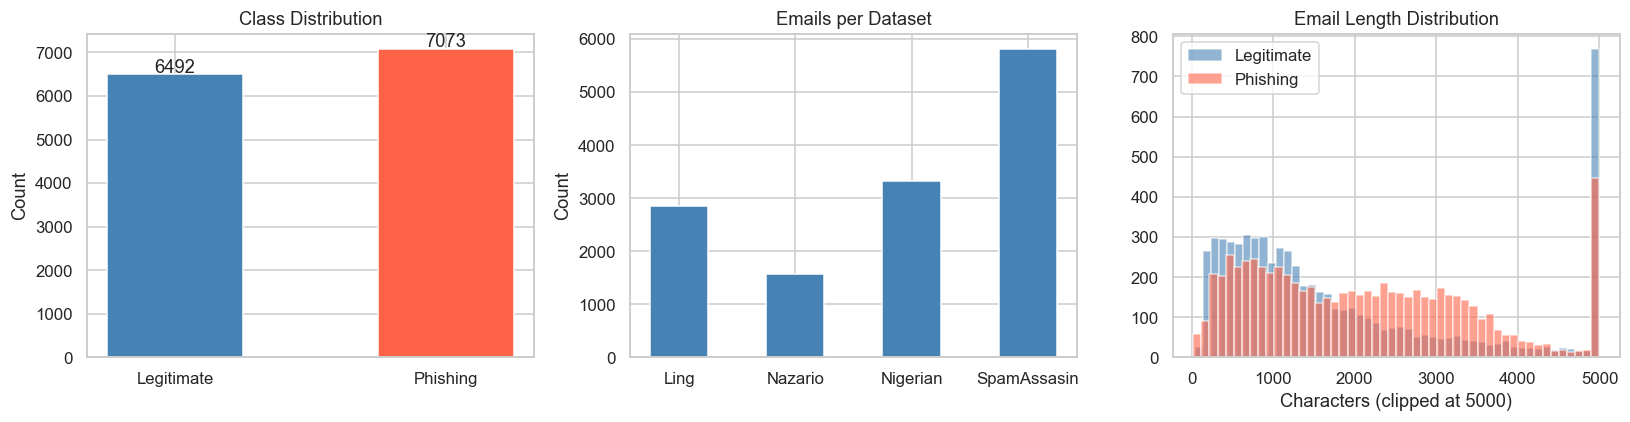

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
counts = combined['label'].value_counts().sort_index()
axes[0].bar(['Legitimate', 'Phishing'], counts.values, color=['steelblue', 'tomato'], width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')
# Dataset sizes
sizes = {'Ling': len(ling), 'Nazario': len(nazario), 'Nigerian': len(nigerian), 'SpamAssasin': len(spam)}
axes[1].bar(sizes.keys(), sizes.values(), color='steelblue', width=0.5)
axes[1].set_title('Emails per Dataset')
axes[1].set_ylabel('Count')
# Email length distribution
combined['text_len'] = combined['text'].str.len()
for label, color, name in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Phishing')]:
    axes[2].hist(combined[combined.label == label]['text_len'].clip(upper=5000),
                 bins=50, alpha=0.6, color=color, label=name)
axes[2].set_title('Email Length Distribution')
axes[2].set_xlabel('Characters (clipped at 5000)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Text Preprocessing

The cleaning pipeline applies the following steps:
1. Lowercase the text
2. Replace URLs, email addresses and numbers with placeholder tokens
3. Remove punctuation
4. Lemmatize - reduce words to their base dictionary form

Stopwords are handled automatically by the TF-IDF vectorizer using `max_df=0.95`, which discards any word that appears in more than 95% of emails. Since common words like *the*, *is*, and *and* appear across virtually every email, they are filtered out from the data itself without any manual list.

**Lemmatization vs Stemming:**  
Lemmatization maps words to their actual dictionary form (e.g. *running* to *run*). Stemming is faster but cruder, simply chopping suffixes (*running* to *runn*). Lemmatization produces more meaningful features for TF-IDF.

In [5]:
def lemmatize(word):
    if len(word) < 4:
        return word
    for suffix, replacement in [('ies','y'), ('ied','y'), ('ness',''), ('ment',''),
                                  ('ing',''), ('tion','te'), ('ed',''), ('er',''), ('ly','')]:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)] + replacement
    return word

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\S+@\S+', ' email ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatize(w) for w in tokens if len(w) > 2]
    return ' '.join(tokens)

combined['cleaned'] = combined['text'].apply(clean_text)

# Sanity check
sample = combined[combined.label == 1].iloc[0]
print('Raw text:')
print(sample['text'][:300])
print('\nCleaned:')
print(sample['cleaned'][:300])

Raw text:
free this is a multi-part message in mime format . - - - - - - = _ nextpart _ 000 _ 0139 _ 01bd8356 . 354ff2e0 content - type : multipart / alternative ; boundary = " - - - - = _ nextpart _ 001 _ 013a _ 01bd8356 . 354ff2e0 " - - - - - - = _ nextpart _ 001 _ 013a _ 01bd8356 . 354ff2e0 content - type 

Cleaned:
free this multipart message mime format nextpart num num num num num num num content type multipart alternative boundary nextpart num num num num num num num nextpart num num num num num num num content type text plain charset iso num num content transf encod num bit scotlandnet make and save the wo


## 5. Feature Extraction - TF-IDF

TF-IDF converts text into a numeric matrix by scoring how important each word is within a document relative to the whole corpus.

- **TF(t, d)** = occurrences of term *t* in document *d* / total terms in *d*
- **IDF(t)** = log( N / df(t) ), where N is total documents and df(t) is documents containing *t*
- **TF-IDF** = TF x IDF

Key parameters:
- `max_df=0.95` — ignores words appearing in more than 95% of emails, removing common words from the data itself
- `min_df=2` — ignores words appearing in fewer than 2 emails, removing noise
- `ngram_range=(1,2)` — captures single words and two-word phrases such as *click here* or *verify account*
- `sublinear_tf=True` — applies log scaling to reduce the weight of very frequent terms

In [6]:
X = combined['cleaned']
y = combined['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training set :', len(X_train), 'emails')
print('Test set     :', len(X_test), 'emails')

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print('Vocabulary size :', len(vectorizer.vocabulary_))
print('Train matrix    :', X_train_tfidf.shape)
print('Test matrix     :', X_test_tfidf.shape)

Training set : 10852 emails
Test set     : 2713 emails
Vocabulary size : 15000
Train matrix    : (10852, 15000)
Test matrix     : (2713, 15000)


## 6. Model Training - Logistic Regression

**Logistic Regression** learns a weight for each word and combines them to produce a probability. The `C=0.1` parameter applies regularisation, which penalises overly large weights and produces more realistic, spread-out probability scores. This makes it better suited to a risk scorer.

In [7]:
lr_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred  = lr_model.predict(X_test_tfidf)
lr_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]
print('Logistic Regression')
print('  Accuracy  :', round(accuracy_score(y_test, lr_pred) * 100, 2), '%')
print('  Recall    :', round(recall_score(y_test, lr_pred) * 100, 2), '%')
print('  F1        :', round(f1_score(y_test, lr_pred) * 100, 2), '%')
print('  Prob range: [{:.2f}, {:.2f}]'.format(lr_proba.min(), lr_proba.max()))

Logistic Regression
  Accuracy  : 97.83 %
  Recall    : 96.54 %
  F1        : 97.89 %
  Prob range: [0.06, 0.97]


## 7. Evaluation Metrics

Recall for the phishing class is the priority metric. A false negative (phishing email that goes undetected) causes more harm than a false positive (a legitimate email incorrectly flagged).

In [8]:
print('--- Logistic Regression ---')
print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Phishing']))

--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.98      1298
    Phishing       0.99      0.97      0.98      1415

    accuracy                           0.98      2713
   macro avg       0.98      0.98      0.98      2713
weighted avg       0.98      0.98      0.98      2713



## 8. Visualisations

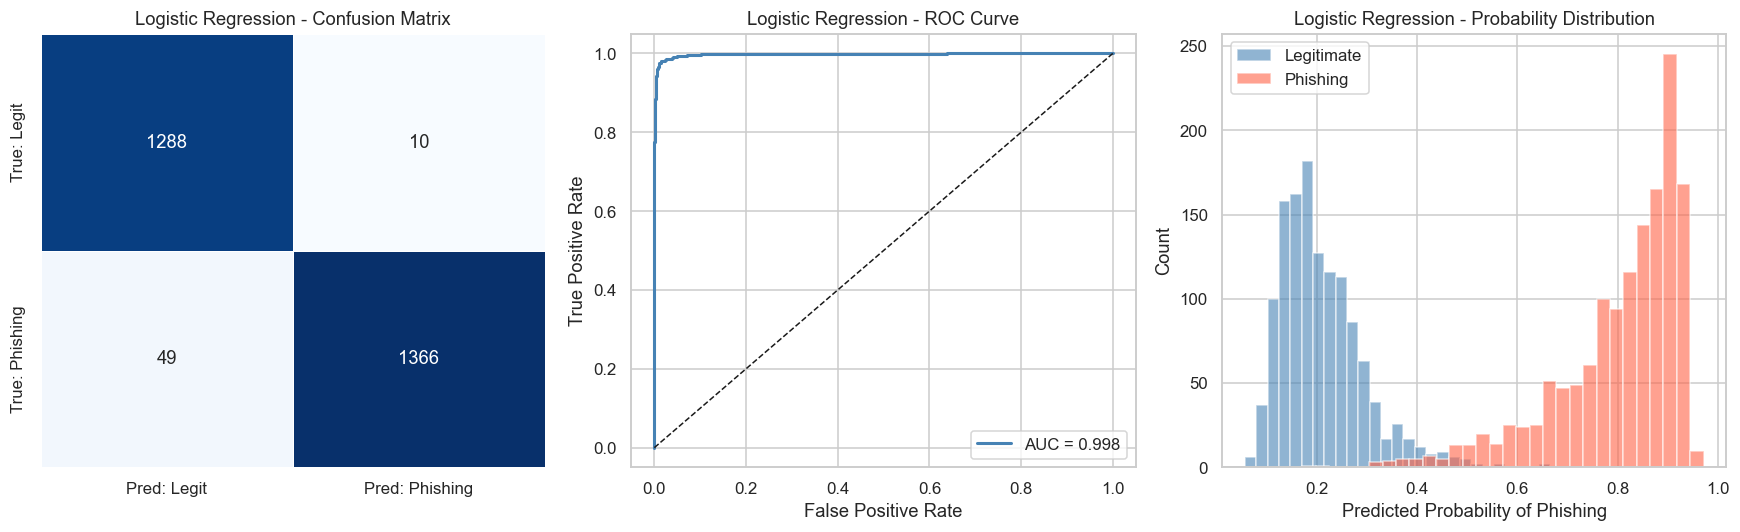

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

name, pred, proba = 'Logistic Regression', lr_pred, lr_proba

# Confusion matrix
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Legit', 'Pred: Phishing'],
            yticklabels=['True: Legit', 'True: Phishing'],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title(f'{name} - Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{name} - ROC Curve')
axes[1].legend()

# Probability distribution
axes[2].hist(proba[y_test == 0], bins=30, alpha=0.6, color='steelblue', label='Legitimate')
axes[2].hist(proba[y_test == 1], bins=30, alpha=0.6, color='tomato', label='Phishing')
axes[2].set_title(f'{name} - Probability Distribution')
axes[2].set_xlabel('Predicted Probability of Phishing')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Cross-Validation
in here we are cross checking for any unfit splits that occurred when data is being split for training and testing. Here since we are splitting data in the propotion of 80-20 for test-train. Here we are performing cross validation 5 times on different splits.

In [10]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                               sublinear_tf=True, min_df=2, max_df=0.95)),
    ('lr', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])

cv_recall   = cross_val_score(pipeline, X, y, cv=5, scoring='recall')
cv_accuracy = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
cv_f1       = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

print('5-Fold Cross-Validation Results - Logistic Regression')
print(f'  Recall   : {cv_recall.mean()*100:.2f}% +/- {cv_recall.std()*100:.2f}%')
print(f'  Accuracy : {cv_accuracy.mean()*100:.2f}% +/- {cv_accuracy.std()*100:.2f}%')
print(f'  F1 Score : {cv_f1.mean()*100:.2f}% +/- {cv_f1.std()*100:.2f}%')

5-Fold Cross-Validation Results - Logistic Regression
  Recall   : 94.29% +/- 6.08%
  Accuracy : 96.27% +/- 3.88%
  F1 Score : 96.25% +/- 3.99%


## 10. Risk Scorer

Uses Logistic Regression which produces well-spread probability scores across the full 0-100 range. The score is entirely driven by patterns the model learned from the training data.

Thresholds: High >= 75%, Medium >= 45%, Low < 45%

In [11]:
def get_risk_score(email_text):
    cleaned    = clean_text(email_text)
    tfidf_vec  = vectorizer.transform([cleaned])
    risk_score = round(lr_model.predict_proba(tfidf_vec)[0][1] * 100, 1)

    if risk_score >= 75:   level = 'HIGH'
    elif risk_score >= 45: level = 'MEDIUM'
    else:                  level = 'LOW'

    return {
        'risk_score' : risk_score,
        'risk_level' : level,
        'verdict'    : 'Phishing' if level in ('HIGH', 'MEDIUM') else 'Legitimate'
    }

test_cases = [
    ("Your account has been suspended. Click here to verify your password immediately or it will be deleted.",
     "Credential phishing"),
    ("Dear Beneficiary, You have inherited $4.5 million. Kindly provide details for wire transfer.",
     "Nigerian fraud"),
    ("We noticed a login to your account from a new device. If this was you, no action is needed.",
     "Ambiguous security notice"),
    ("Your package could not be delivered. Please confirm your address to reschedule.",
     "Ambiguous delivery notice"),
    ("Hi Sarah, the meeting is scheduled for 3 PM tomorrow in conference room B. Please bring the Q3 report.",
     "Legitimate"),
    ("The quarterly report has been attached. Let me know if you have any questions.",
     "Legitimate"),
]

for email, label in test_cases:
    r = get_risk_score(email)
    print(f'[{label}]')
    print(f'  Text    : {email[:80]}')
    print(f'  Risk    : {r["risk_score"]}% [{r["risk_level"]}] -> {r["verdict"]}')
    print()

[Credential phishing]
  Text    : Your account has been suspended. Click here to verify your password immediately 
  Risk    : 91.9% [HIGH] -> Phishing

[Nigerian fraud]
  Text    : Dear Beneficiary, You have inherited $4.5 million. Kindly provide details for wi
  Risk    : 76.3% [HIGH] -> Phishing

[Ambiguous security notice]
  Text    : We noticed a login to your account from a new device. If this was you, no action
  Risk    : 76.3% [HIGH] -> Phishing

[Ambiguous delivery notice]
  Text    : Your package could not be delivered. Please confirm your address to reschedule.
  Risk    : 67.2% [MEDIUM] -> Phishing

[Legitimate]
  Text    : Hi Sarah, the meeting is scheduled for 3 PM tomorrow in conference room B. Pleas
  Risk    : 36.6% [LOW] -> Legitimate

[Legitimate]
  Text    : The quarterly report has been attached. Let me know if you have any questions.
  Risk    : 59.1% [MEDIUM] -> Phishing



## 11. Main Input Section

In [12]:
# Paste the suspcious email text here and run the cell
my_email = """
Dear User,

We noticed unusual activity on your account.
Please verify your identity by clicking the link below within 24 hours,
or your account will be suspended.

http://verify-account-secure.xyz/login

Regards,
Security Team
"""

result = get_risk_score(my_email)

print('Risk Score :', result['risk_score'], '%')
print('Risk Level :', result['risk_level'])
print('Verdict    :', result['verdict'])

Risk Score : 89.6 %
Risk Level : HIGH
Verdict    : Phishing
